<a href="https://colab.research.google.com/github/KhenCahyo13/MyCampus-Jobsheet/blob/smt-5/pcvk/week-6/Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [32]:
import cv2 as cv
import numpy as np
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# D. Filter Practicum

In [10]:
# Create convolution2d function
def convolution2d(image, kernel, padding=0, strides=1):
    image_row, image_col = image.shape
    kernel_row, kernel_col = kernel.shape
    pad_img = np.zeros((image_row + 2 * padding, image_col + 2 * padding))
    pad_img[padding:padding + image_row, padding:padding + image_col] = image
    output = np.zeros(((image_row - kernel_row + 2 * padding) // strides + 1,
                       (image_col - kernel_col + 2 * padding) // strides + 1))
    for y in range(0, output.shape[0]):
        for x in range(0, output.shape[1]):
            output[y, x] = np.sum(kernel * pad_img[y * strides:y * strides + kernel_row,
                                                   x * strides:x * strides + kernel_col])
    return output

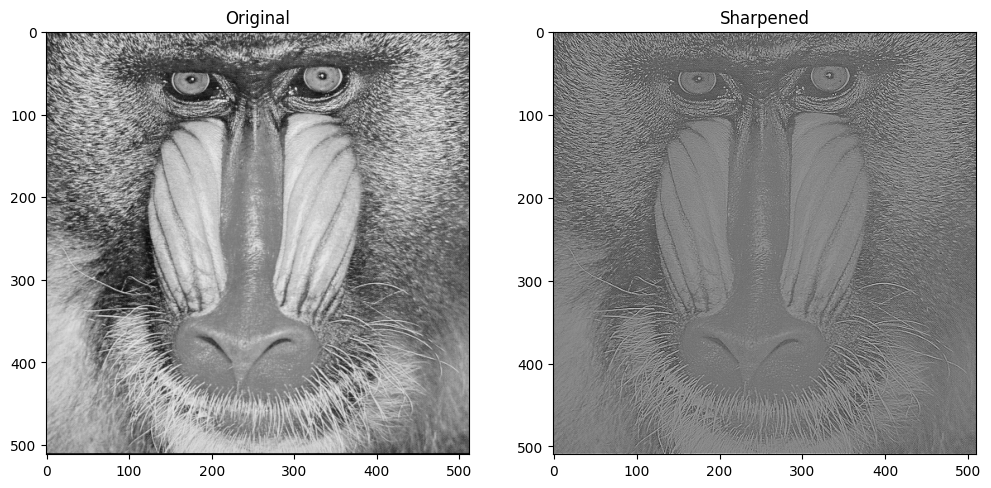

In [41]:
# Sharpened img
img_sharpen = cv.imread('mandrill.tiff', cv.IMREAD_GRAYSCALE)

kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])

sharpened_img = convolution2d(img_sharpen, kernel_sharpen)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(img_sharpen, cmap='gray'), plt.title('Original')
plt.subplot(1, 2, 2), plt.imshow(sharpened_img, cmap='gray'), plt.title('Sharpened')
plt.show()

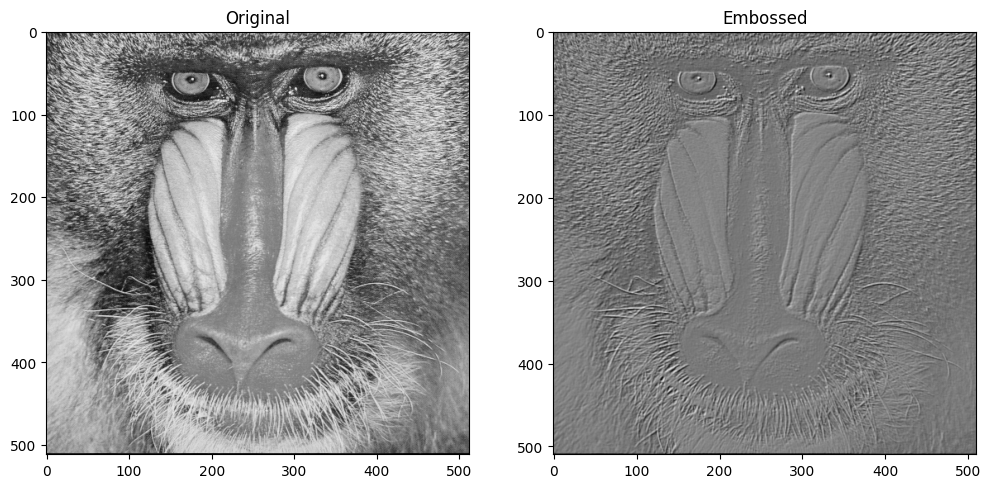

In [42]:
# Embossed img
img_emboss = cv.imread('mandrill.tiff', cv.IMREAD_GRAYSCALE)
kernel_emboss = np.array([[-2, -1, 0],
                           [-1, 1, 1],
                           [0, 1, 2]])

embossed_img = convolution2d(img_emboss, kernel_emboss)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(img_emboss, cmap='gray'), plt.title('Original')
plt.subplot(1, 2, 2), plt.imshow(embossed_img, cmap='gray'), plt.title('Embossed')
plt.show()

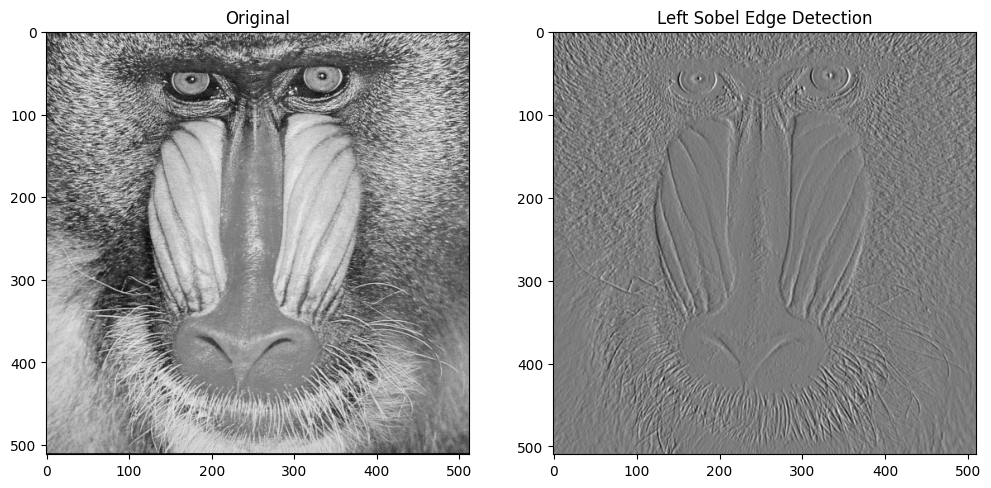

In [43]:
# Left Sobel Edge Detection img
img_lsed = cv.imread('mandrill.tiff', cv.IMREAD_GRAYSCALE)
kernel_lsed = np.array([[1, 0, -1],
                           [2, 0, -2],
                           [1, 0, -1]])

lsed_img = convolution2d(img_lsed, kernel_lsed)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(img_lsed, cmap='gray'), plt.title('Original')
plt.subplot(1, 2, 2), plt.imshow(lsed_img, cmap='gray'), plt.title('Left Sobel Edge Detection')
plt.show()

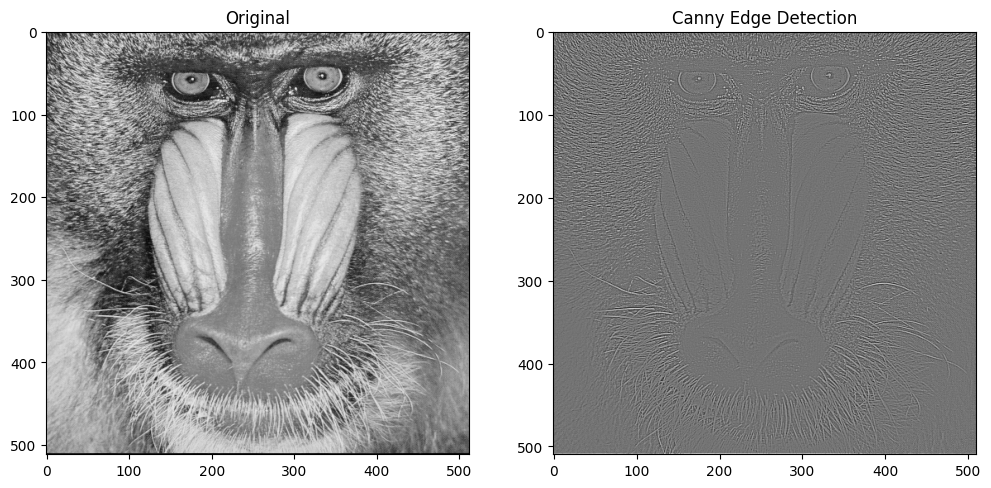

In [44]:
# Canny Edge Detection img
img_canny = cv.imread('mandrill.tiff', cv.IMREAD_GRAYSCALE)
kernel_canny = np.array([[-1, -1, -1],
                         [-1,  8, -1],
                         [-1, -1, -1]])

canny_img = convolution2d(img_canny, kernel_canny)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(img_canny, cmap='gray'), plt.title('Original')
plt.subplot(1, 2, 2), plt.imshow(canny_img, cmap='gray'), plt.title('Canny Edge Detection')
plt.show()

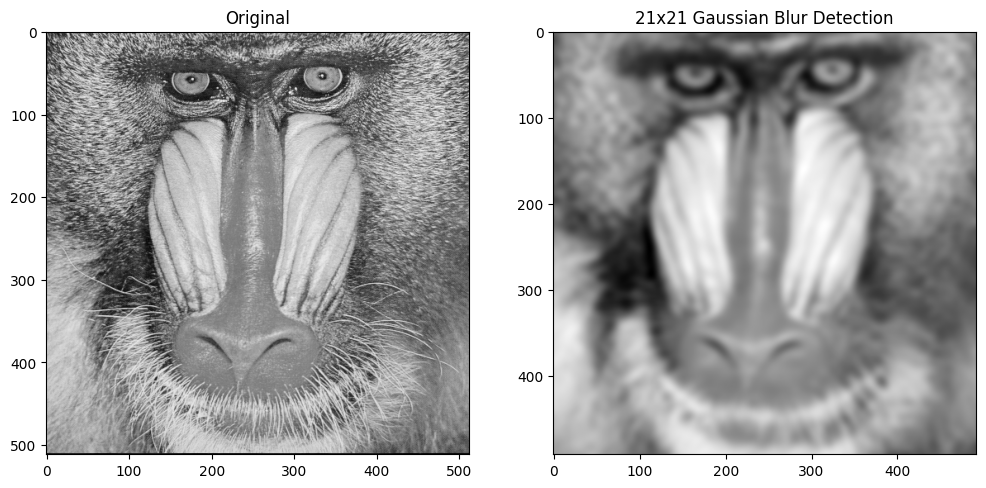

In [45]:
# 21x21 Gaussian Blur
img_gaussian = cv.imread('mandrill.tiff', cv.IMREAD_GRAYSCALE)

kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel_1d = cv.getGaussianKernel(kernel_size, sigma)
gaussian_kernel = gaussian_kernel_1d @ gaussian_kernel_1d.T
gaussian_filtered = convolution2d(img_gaussian, gaussian_kernel)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(img_gaussian, cmap='gray'), plt.title('Original')
plt.subplot(1, 2, 2), plt.imshow(gaussian_filtered, cmap='gray'), plt.title('21x21 Gaussian Blur Detection')
plt.show()

# E. Filter Library & Modern Filter

In [28]:
# Show side-by-side function
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

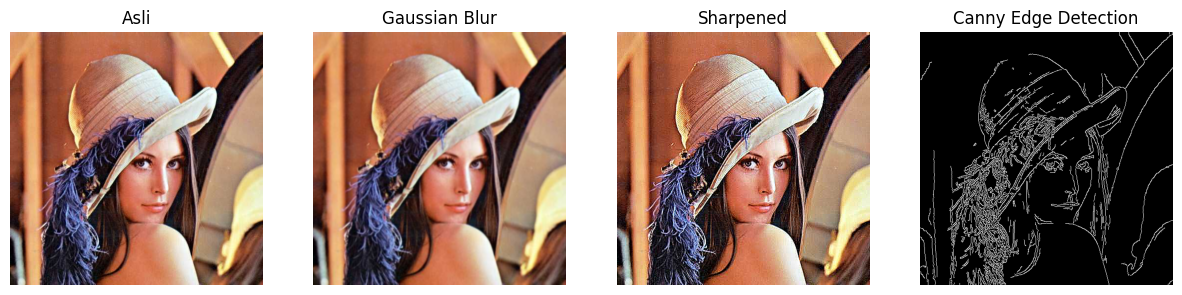

In [46]:
# Experiment 1
img = cv.imread("lena.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)

show_side_by_side(
    [img, blur, sharpened, edges],
    ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"]
)

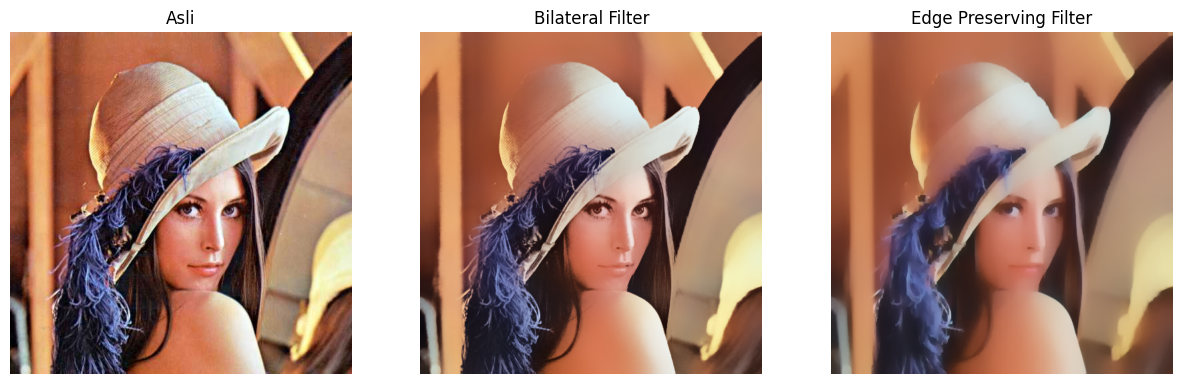

In [47]:
# Experiment 2

# Bilateral Filtering
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve], ['Asli', 'Bilateral Filter', 'Edge Preserving Filter'])

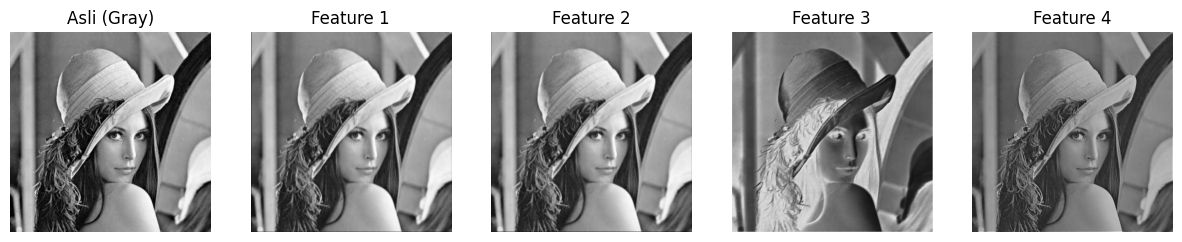

In [48]:
# Experiment 3
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Change image to tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# CNN results
with torch.no_grad():
    features = model(img_tensor)

# Feature maps visualization
feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]
show_side_by_side(
    [img_gray] + feature_maps,
    ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))]
)


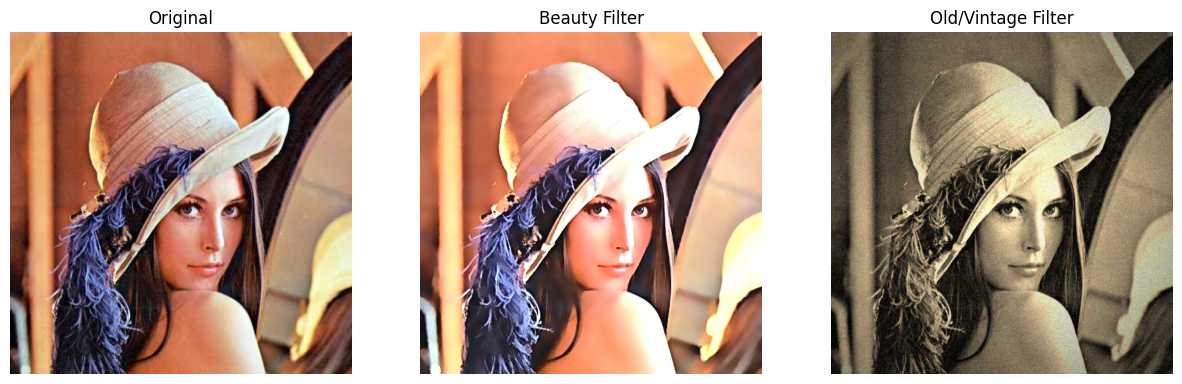

In [49]:
# Experiment 4

# 1. Beauty Filter

# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2   # contrast
beta = 15     # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)


# 2. Old/Vintage Filter

# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side(
    [img, beauty, old_img],
    ["Original", "Beauty Filter", "Old/Vintage Filter"]
)

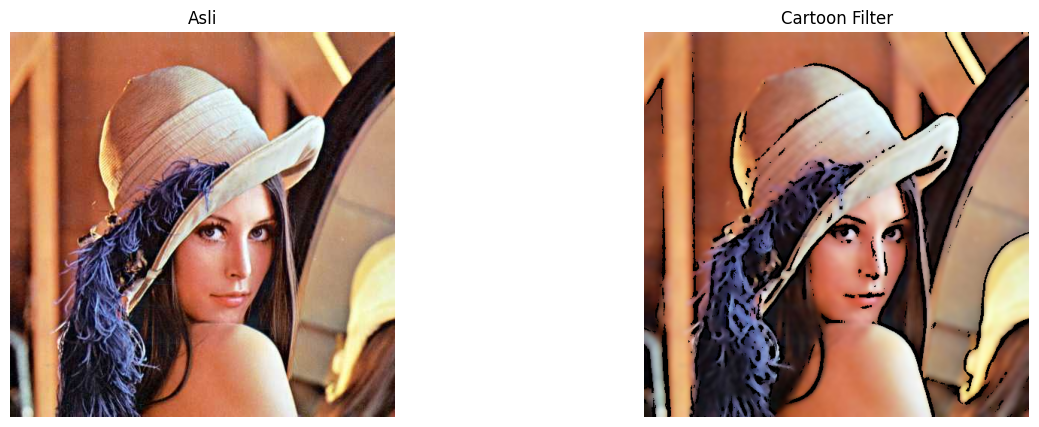

In [50]:
# Experiment 5
# Filter Anime / Cartoon

# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

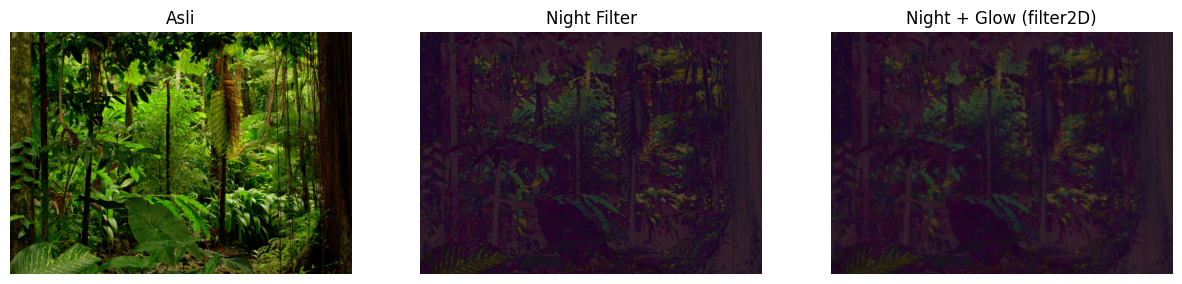

In [51]:
# Experiment 6
# Night Filter
img = cv.imread("hutan.png")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (filter2D)"])

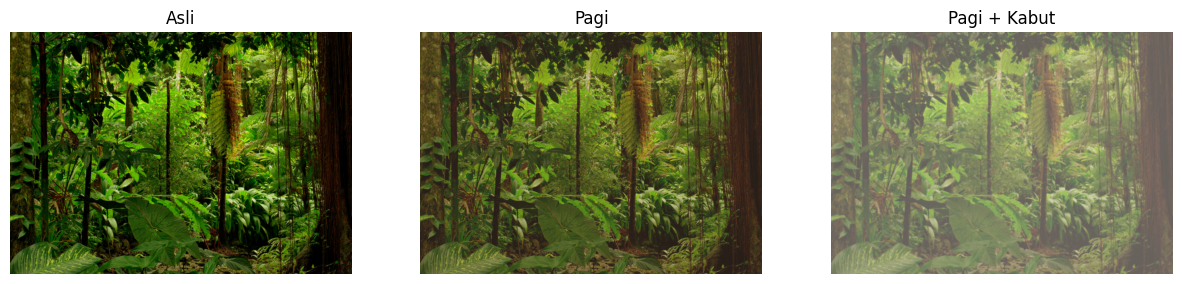

In [52]:
# Experiment 7
# Filter Suasana pagi dan Kabut
# =============================
# Step 1: Kurangi kontras & cerahkan
# =============================
alpha = 0.9   # contrast
beta = 20     # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# =============================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# =============================
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# =============================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# =============================

# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah Layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])